# 2 — Feature Engineering

Goals:
- Add all technical indicators using `indicators.py`
- Visualize key features (RSI, MACD, Bollinger Bands)
- Analyze feature correlation with next-day direction target
- Save processed data for model training

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import load_all_stocks, load_metadata
from src.indicators import add_all_indicators

sns.set_style('whitegrid')
%matplotlib inline

## 2.1 Add Indicators to All Stocks

In [2]:
stocks = load_all_stocks()

# Add indicators to every stock
for sym in stocks:
    stocks[sym] = add_all_indicators(stocks[sym])

# Check one stock
df = stocks['TCS']
print(f'TCS shape after indicators: {df.shape}')
print(f'\nNew columns: {[c for c in df.columns if c not in ["Open","High","Low","Close","Volume","Turnover","VWAP","Prev Close","Symbol"]]}')

TCS shape after indicators: (4139, 37)

New columns: ['Returns', 'Log_Returns', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'Price_vs_SMA20', 'Price_vs_SMA50', 'Price_vs_SMA200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Lower', 'BB_Width', 'BB_Position', 'ATR', 'Volatility_20', 'Volume_Ratio', 'Returns_Lag1', 'Returns_Lag2', 'Returns_Lag3', 'Returns_Lag5', 'DayOfWeek', 'Month', 'Target']


## 2.2 Visualize Technical Indicators — TCS Example

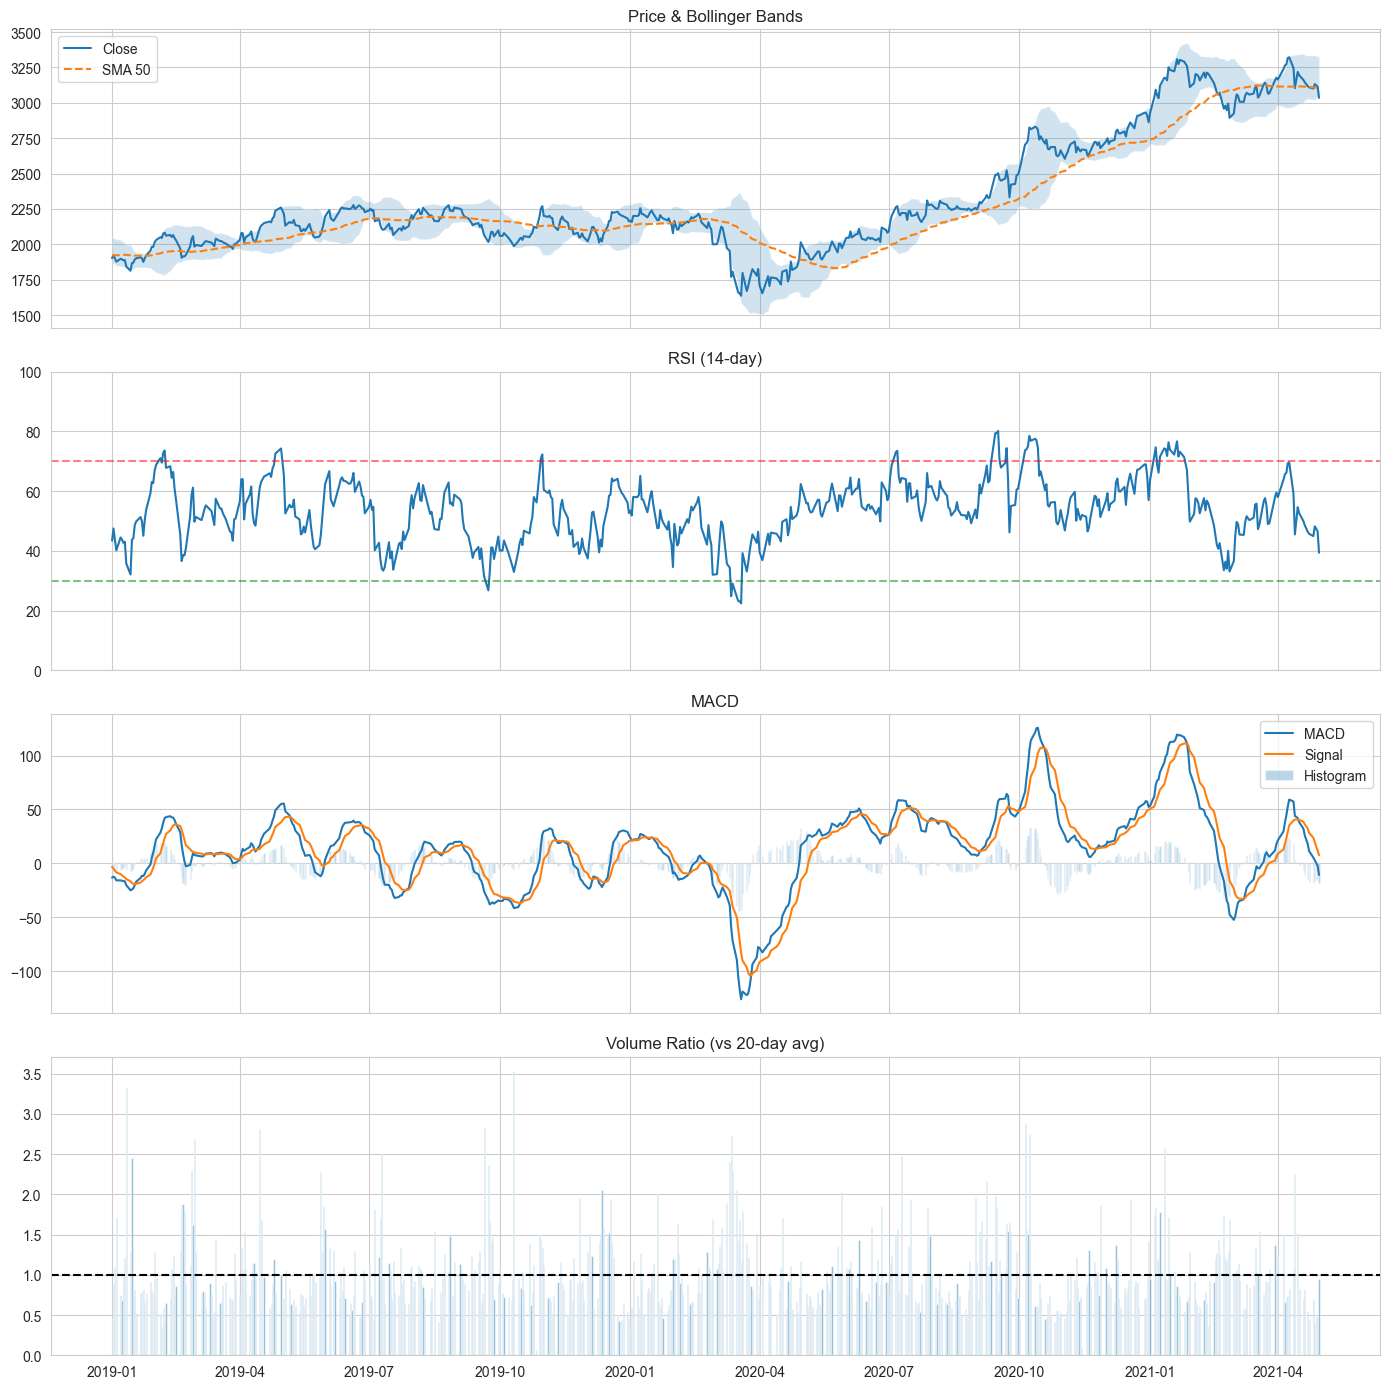

In [3]:
recent = df.loc['2019':]

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Price + Bollinger Bands
axes[0].plot(recent['Close'], label='Close')
axes[0].fill_between(recent.index, recent['BB_Upper'], recent['BB_Lower'], alpha=0.2)
axes[0].plot(recent['SMA_50'], '--', label='SMA 50')
axes[0].set_title('Price & Bollinger Bands')
axes[0].legend()

# RSI
axes[1].plot(recent['RSI'])
axes[1].axhline(70, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5)
axes[1].set_title('RSI (14-day)')
axes[1].set_ylim(0, 100)

# MACD
axes[2].plot(recent['MACD'], label='MACD')
axes[2].plot(recent['MACD_Signal'], label='Signal')
axes[2].bar(recent.index, recent['MACD_Hist'], alpha=0.3, label='Histogram')
axes[2].set_title('MACD')
axes[2].legend()

# Volume Ratio
axes[3].bar(recent.index, recent['Volume_Ratio'], alpha=0.6)
axes[3].axhline(1, color='black', linestyle='--')
axes[3].set_title('Volume Ratio (vs 20-day avg)')

plt.tight_layout()
plt.show()

## 2.3 Feature Distributions

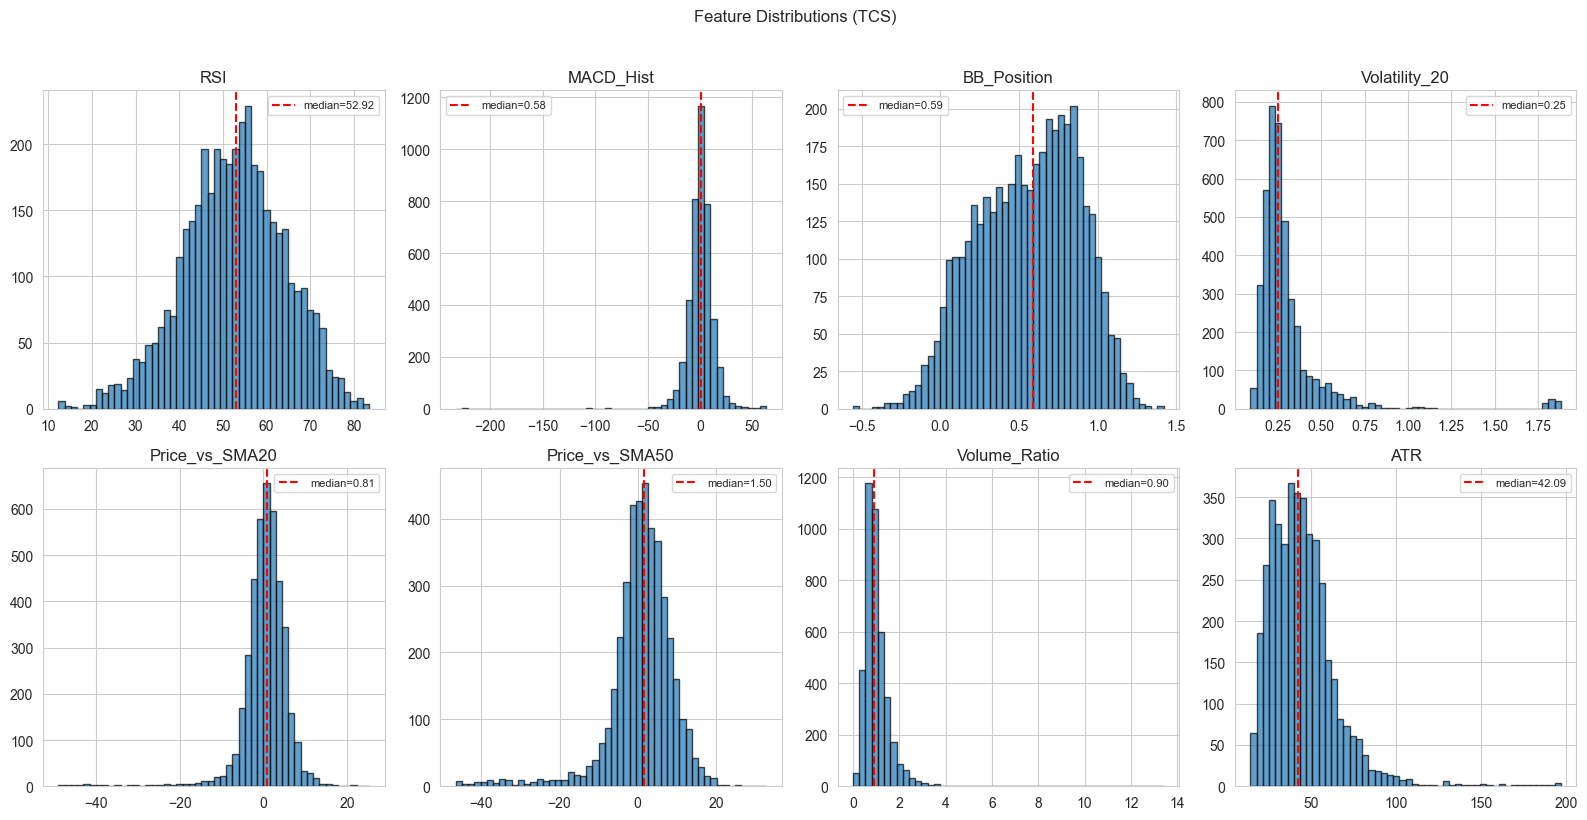

In [4]:
feature_cols = ['RSI', 'MACD_Hist', 'BB_Position', 'Volatility_20',
                'Price_vs_SMA20', 'Price_vs_SMA50', 'Volume_Ratio', 'ATR']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, feature_cols):
    data = df[col].dropna()
    ax.hist(data, bins=50, alpha=0.7, edgecolor='black')
    ax.set_title(col)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'median={data.median():.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions (TCS)', y=1.02)
plt.tight_layout()
plt.show()

## 2.4 Feature Correlation with Target

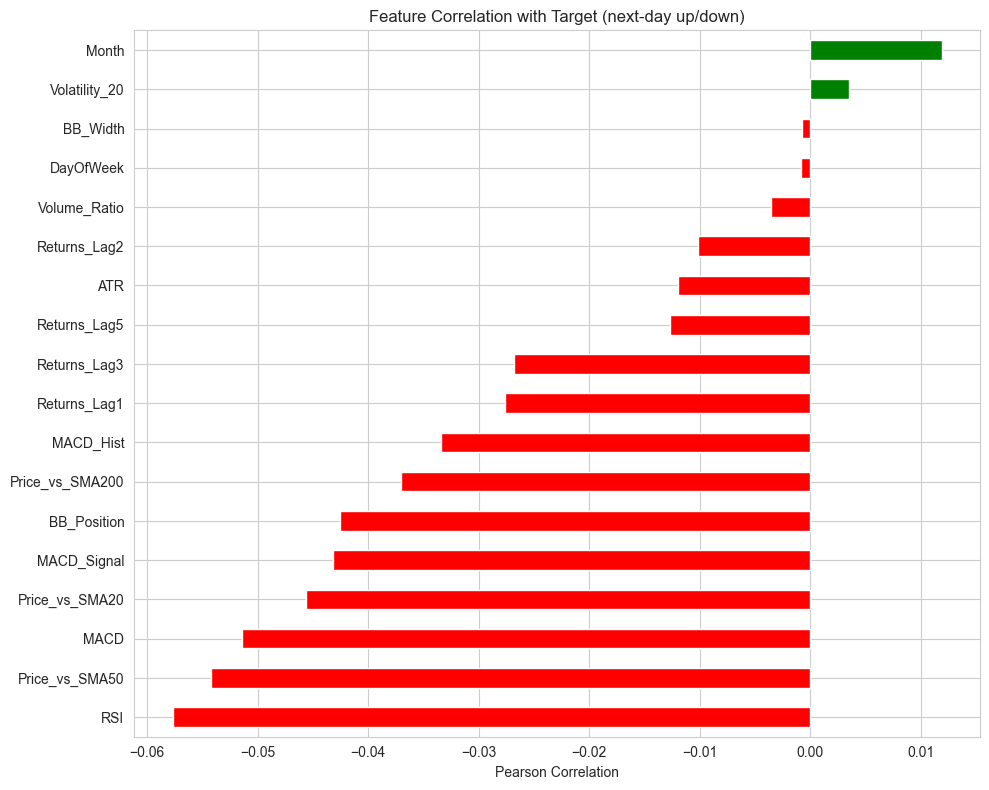

In [5]:
all_features = [
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Position', 'BB_Width', 'ATR',
    'Price_vs_SMA20', 'Price_vs_SMA50', 'Price_vs_SMA200',
    'Volatility_20', 'Volume_Ratio',
    'Returns_Lag1', 'Returns_Lag2', 'Returns_Lag3', 'Returns_Lag5',
    'DayOfWeek', 'Month', 'Target',
]

corr_with_target = df[all_features].corr()['Target'].drop('Target').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.plot.barh(ax=ax, color=['red' if v < 0 else 'green' for v in corr_with_target])
ax.set_title('Feature Correlation with Target (next-day up/down)')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## 2.5 Feature Correlation Matrix

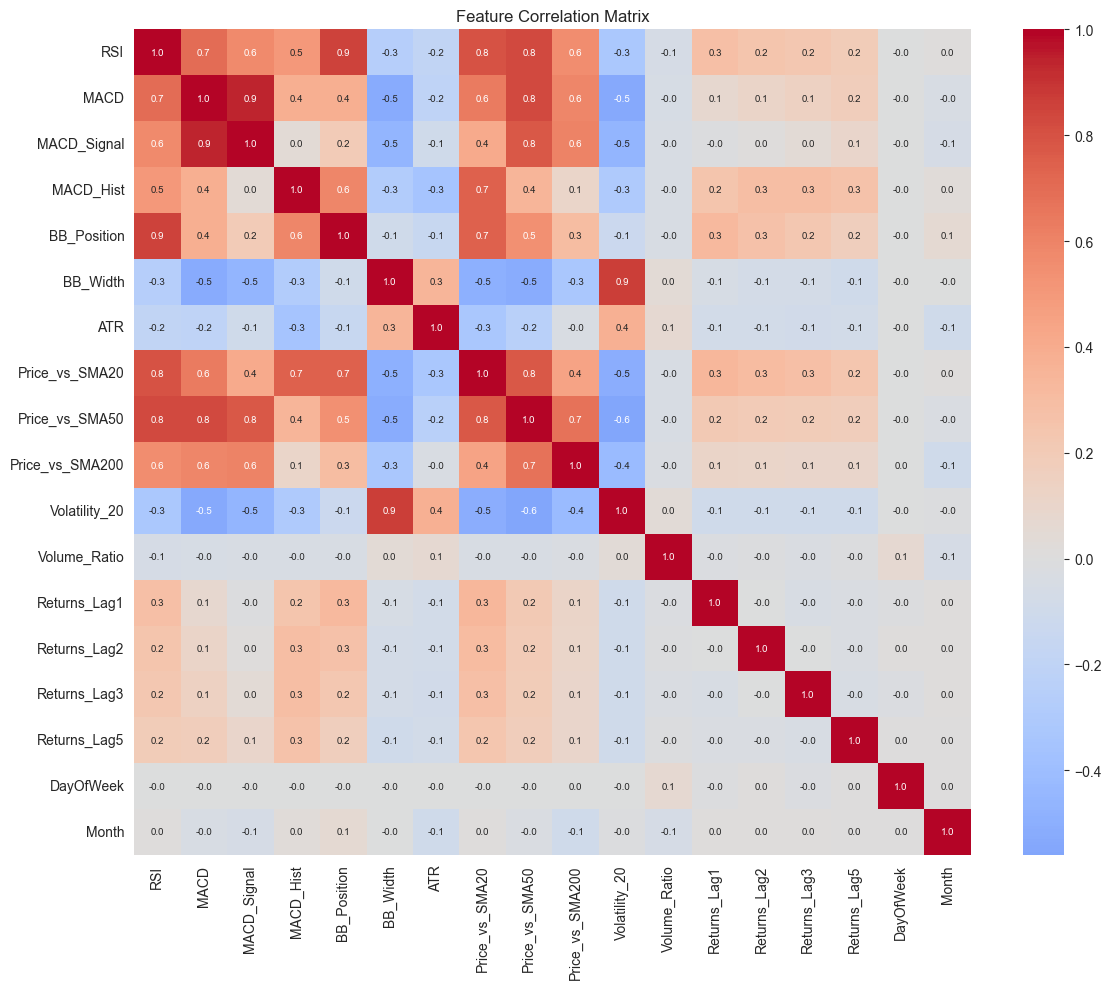

In [6]:
corr = df[all_features[:-1]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.1f', ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 2.6 Save Processed Data

In [7]:
from pathlib import Path

processed_dir = Path('..') / 'data' / 'processed'
processed_dir.mkdir(exist_ok=True)

# Pool all stocks into one DataFrame with indicator columns
frames = []
for sym, df in stocks.items():
    clean = df.dropna(subset=['Target'])
    frames.append(clean)

pooled = pd.concat(frames)
pooled.to_parquet(processed_dir / 'all_stocks_with_indicators.parquet')
print(f'Saved {len(pooled)} rows to data/processed/all_stocks_with_indicators.parquet')

Saved 235192 rows to data/processed/all_stocks_with_indicators.parquet


## 2.7 Key Observations

- **25+ features** engineered from raw OHLCV data
- **Low individual correlation** with target — expected for daily stock direction
- **Some multicollinearity** between MACD/EMA features (by design)
- **Lag features** capture short-term momentum effects
- Processed data saved for direct use in prediction notebook